# LightGBM — A Beginner-Friendly Learning Notebook

This notebook teaches **LightGBM classification** through a complete project.

We will:

1. Understand LightGBM in plain language.
2. Create separate **training, validation, and test** sets.
3. Train an `LGBMClassifier`.
4. Use validation data for native **early stopping**.
5. Retrain a final model using the selected number of trees.
6. Evaluate once on the untouched test set.
7. Explain every model and fit parameter used in simple language.
8. Inspect learning curves, probabilities, and feature importance.
9. Save and reload the model.

The notebook uses the built-in scikit-learn breast-cancer dataset, so no dataset download is required.

## 1. What is LightGBM?

**LightGBM** means **Light Gradient Boosting Machine**.

The simple idea:

- Build a decision tree.
- Measure the errors made by the current group of trees.
- Add another tree that reduces those errors.
- Continue until performance stops improving.

LightGBM is designed for efficient training on tabular data. It converts continuous values into **histogram bins** when searching for splits, which reduces computational work.

LightGBM commonly grows trees **leaf-wise**:

- It finds the leaf where another split would improve the objective the most.
- It splits that leaf first.
- This can learn complex patterns quickly, but parameters such as `num_leaves`, `max_depth`, and `min_child_samples` must control complexity.

## 2. Why use training, validation, and test sets?

| Dataset | Used for | Simple meaning |
|---|---|---|
| **Training set** | Learn tree rules | The model studies this data. |
| **Validation set** | Early stopping and model selection | A practice exam. |
| **Test set** | One final unbiased evaluation | The final exam. |

We use approximately:

- **70% training**
- **15% validation**
- **15% test**

The test set stays untouched until all model decisions are complete.

## 3. Install packages

In [1]:
# %pip install -q lightgbm scikit-learn pandas numpy matplotlib joblib

## 4. Imports and reproducibility

In [2]:
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

print('LightGBM version:', lgb.__version__)
print('scikit-learn version:', sklearn.__version__)

LightGBM version: 4.6.0
scikit-learn version: 1.8.0


### Why `random_state=42`?

A fixed random seed makes data splitting and sampling repeatable. The number itself has no special machine-learning meaning.

## 5. Load the dataset

In [3]:
data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = data.target.copy()
class_names = list(data.target_names)

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Classes:', dict(enumerate(class_names)))
X.head()

Feature matrix shape: (569, 30)
Target shape: (569,)
Classes: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Important terms

- **Boosting round / tree:** One new tree added to correct the current ensemble.
- **Leaf:** A final tree branch containing a prediction value.
- **Histogram bin:** A bucket containing a range of numeric values.
- **Objective:** The mathematical training goal.
- **Metric:** A number used to monitor performance.
- **Early stopping:** Stop when validation performance does not improve for a chosen number of rounds.

In [4]:
summary = pd.DataFrame({
    'dtype': X.dtypes.astype(str),
    'missing_values': X.isna().sum(),
    'minimum': X.min(),
    'maximum': X.max(),
    'mean': X.mean(),
})

print('Missing values:', int(X.isna().sum().sum()))
print('\nClass counts:')
print(y.value_counts().rename(index={0: class_names[0], 1: class_names[1]}))
summary.head(10)

Missing values: 0

Class counts:
target
benign       357
malignant    212
Name: count, dtype: int64


,dtype,missing_values,minimum,maximum,mean
mean radius,float64,0,6.98100,28.11000,14.127292
mean texture,float64,0,9.71000,39.28000,19.289649
mean perimeter,float64,0,43.79000,188.50000,91.969033
mean area,float64,0,143.50000,2501.00000,654.889104
mean smoothness,float64,0,0.05263,0.16340,0.096360
mean compactness,float64,0,0.01938,0.34540,0.104341
mean concavity,float64,0,0.00000,0.42680,0.088799
mean concave points,float64,0,0.00000,0.20120,0.048919
mean symmetry,float64,0,0.10600,0.30400,0.181162
mean fractal dimension,float64,0,0.04996,0.09744,0.062798


## 6. Split into training, validation, and test sets

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    'rows': [len(X_train), len(X_validation), len(X_test)],
    'percentage': [len(X_train) / len(X), len(X_validation) / len(X), len(X_test) / len(X)],
    'positive_class_rate': [y_train.mean(), y_validation.mean(), y_test.mean()],
}, index=['Training', 'Validation', 'Test'])

split_summary.style.format({'percentage': '{:.1%}', 'positive_class_rate': '{:.1%}'})

,rows,percentage,positive_class_rate
Training,398,69.9%,62.8%
Validation,85,14.9%,62.4%
Test,86,15.1%,62.8%


## 7. Parameters used in our LightGBM model

| Parameter | Value | Simple meaning |
|---|---:|---|
| `objective` | `'binary'` | Train for a two-class classification problem. |
| `boosting_type` | `'gbdt'` | Use ordinary gradient-boosted decision trees. |
| `n_estimators` | `2000` | Maximum number of trees. Early stopping will normally use fewer. |
| `learning_rate` | `0.10` | Contribution made by every new tree. This moderate value lets early stopping become visible in the example. |
| `num_leaves` | `15` | Maximum number of final leaves in one tree. Controls tree complexity. |
| `max_depth` | `-1` | Do not impose a separate depth limit. Complexity is mainly controlled by leaves and minimum rows. |
| `min_child_samples` | `20` | Minimum training rows required in a leaf. Larger values create simpler trees. |
| `subsample` | `0.8` | Use 80% of training rows for a sampled tree. |
| `subsample_freq` | `1` | Perform row sampling every boosting round. A value of `0` would disable it. |
| `colsample_bytree` | `0.8` | Use 80% of features for each tree. |
| `reg_alpha` | `0.0` | L1 regularization strength. Zero means disabled. |
| `reg_lambda` | `1.0` | L2 regularization strength. Helps discourage extreme leaf values. |
| `random_state` | `42` | Makes sampling repeatable. |
| `n_jobs` | `2` | Use two CPU threads. This is predictable on laptops and hosted notebooks. |
| `verbosity` | `-1` | Hide routine training messages. |

## 8. Create the model

In [6]:
model_parameters = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'n_estimators': 2000,
    'learning_rate': 0.10,
    'num_leaves': 15,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'random_state': RANDOM_STATE,
    'n_jobs': 2,
    'verbosity': -1,
}

candidate_model = LGBMClassifier(**model_parameters)
candidate_model

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,-1
,learning_rate,0.1
,n_estimators,2000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 9. Train with validation-based early stopping

### Fit parameters and callbacks

| Setting | Simple meaning |
|---|---|
| `eval_set` | Datasets LightGBM evaluates after every boosting round. |
| `eval_names` | Friendly names used in the stored evaluation history. |
| `eval_metric='binary_logloss'` | Monitor probability error; lower is better. |
| `early_stopping(75)` | Stop when validation log loss fails to improve for 75 rounds. |
| `log_evaluation(0)` | Do not print a line after every round. |

The training set may continue improving while validation performance stops improving. Early stopping selects the iteration with the best validation score.

In [7]:
candidate_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_validation, y_validation)],
    eval_names=['training', 'validation'],
    eval_metric='binary_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=75, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)

print('Best iteration:', candidate_model.best_iteration_)
print('Best validation score:', candidate_model.best_score_['validation']['binary_logloss'])

Best iteration: 404
Best validation score: 0.018688963745272336


## 10. Plot the learning curve

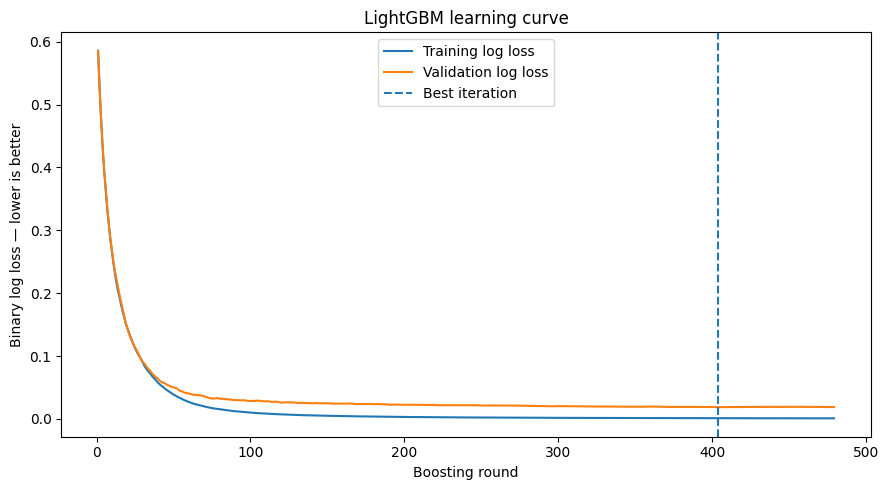

In [8]:
evaluation_history = candidate_model.evals_result_
train_loss = evaluation_history['training']['binary_logloss']
validation_loss = evaluation_history['validation']['binary_logloss']
rounds = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(9, 5))
plt.plot(rounds, train_loss, label='Training log loss')
plt.plot(rounds, validation_loss, label='Validation log loss')
plt.axvline(candidate_model.best_iteration_, linestyle='--', label='Best iteration')
plt.xlabel('Boosting round')
plt.ylabel('Binary log loss — lower is better')
plt.title('LightGBM learning curve')
plt.legend()
plt.tight_layout()
plt.show()

### Reading the graph

- A falling training curve means the model is fitting the training data.
- A falling validation curve means generalization is improving.
- If training loss keeps falling while validation loss rises, the model is overfitting.
- Early stopping keeps the best validation iteration rather than blindly using all 2,000 trees.

## 11. A reusable evaluation function

In [9]:
def evaluate_classifier(model, X_eval, y_eval, set_name='Dataset'):
    """Print useful binary-classification metrics and draw two diagnostic plots."""
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]

    metrics = pd.Series({
        'Accuracy': accuracy_score(y_eval, predictions),
        'Precision': precision_score(y_eval, predictions, zero_division=0),
        'Recall': recall_score(y_eval, predictions, zero_division=0),
        'F1 score': f1_score(y_eval, predictions, zero_division=0),
        'ROC AUC': roc_auc_score(y_eval, probabilities),
        'Log loss': log_loss(y_eval, probabilities),
    }, name=set_name)

    display(metrics.to_frame().round(4))
    print(classification_report(
        y_eval,
        predictions,
        target_names=class_names,
        zero_division=0,
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_eval,
        predictions,
        display_labels=class_names,
    )
    plt.title(f'{set_name}: confusion matrix')
    plt.tight_layout()
    plt.show()

    RocCurveDisplay.from_predictions(y_eval, probabilities)
    plt.title(f'{set_name}: ROC curve')
    plt.tight_layout()
    plt.show()

    return metrics

### Metric meanings

| Metric | Simple meaning |
|---|---|
| **Accuracy** | Fraction of all predictions that are correct. |
| **Precision** | When class 1 is predicted, how often is it correct? |
| **Recall** | Of all real class-1 rows, how many were found? |
| **F1 score** | Balance between precision and recall. |
| **ROC AUC** | Ranking ability across many probability thresholds. |
| **Log loss** | Probability error; confident wrong predictions are penalized heavily. Lower is better. |

## 12. Evaluate the early-stopped model on validation data

,Validation set
Accuracy,0.9882
Precision,0.9815
Recall,1.0000
F1 score,0.9907
ROC AUC,1.0000
Log loss,0.0187


              precision    recall  f1-score   support

   malignant       1.00      0.97      0.98        32
      benign       0.98      1.00      0.99        53

    accuracy                           0.99        85
   macro avg       0.99      0.98      0.99        85
weighted avg       0.99      0.99      0.99        85



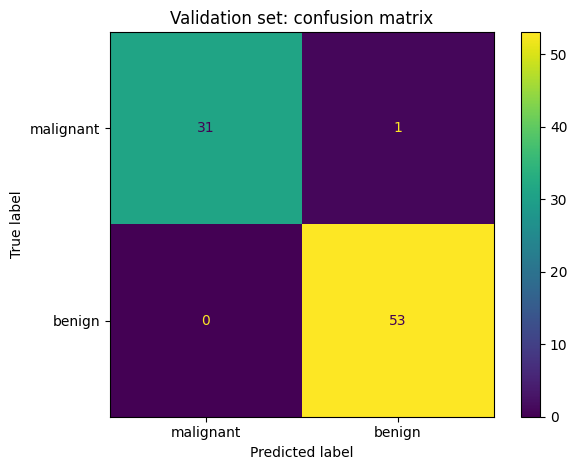

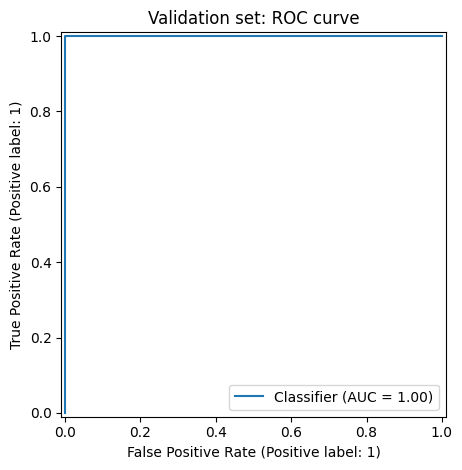

In [10]:
validation_metrics = evaluate_classifier(
    candidate_model,
    X_validation,
    y_validation,
    set_name='Validation set',
)

## 13. Retrain on training + validation data

The validation set selected the best number of trees. We now train a fresh model on all development data using exactly that number.

No early stopping is needed in this retraining step because the tree count has already been chosen.

In [11]:
X_development = pd.concat([X_train, X_validation], axis=0)
y_development = pd.concat([y_train, y_validation], axis=0)

best_iteration = int(candidate_model.best_iteration_)
final_parameters = model_parameters.copy()
final_parameters['n_estimators'] = best_iteration

final_model = LGBMClassifier(**final_parameters)
final_model.fit(
    X_development,
    y_development,
    callbacks=[lgb.log_evaluation(period=0)],
)

print('Development rows:', len(X_development))
print('Final number of trees:', final_model.n_estimators_)

Development rows: 483
Final number of trees: 404


## 14. Final evaluation on the untouched test set

,Untouched test set
Accuracy,0.9302
Precision,0.9138
Recall,0.9815
F1 score,0.9464
ROC AUC,0.9774
Log loss,0.2319


              precision    recall  f1-score   support

   malignant       0.96      0.84      0.90        32
      benign       0.91      0.98      0.95        54

    accuracy                           0.93        86
   macro avg       0.94      0.91      0.92        86
weighted avg       0.93      0.93      0.93        86



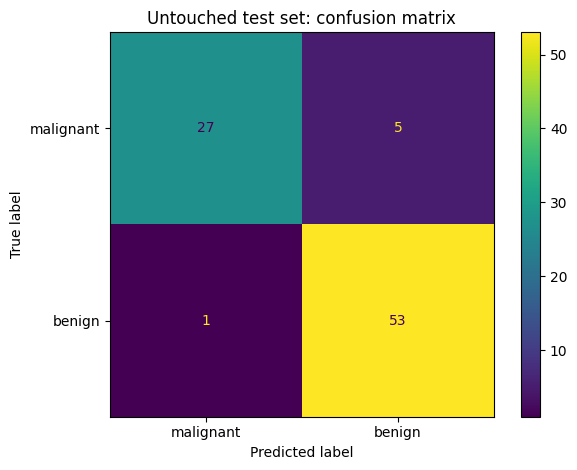

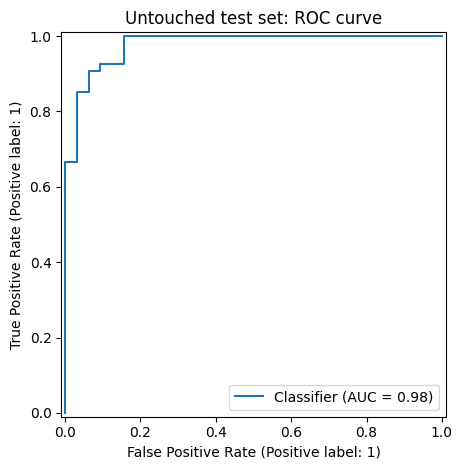

In [12]:
test_metrics = evaluate_classifier(
    final_model,
    X_test,
    y_test,
    set_name='Untouched test set',
)

Do not repeatedly tune the model after inspecting these test results. That would gradually leak test information into model development.

## 15. Inspect predicted probabilities

In [13]:
probability_examples = pd.DataFrame(index=X_test.head(10).index)
probability_examples['actual_class'] = y_test.head(10).map(dict(enumerate(class_names)))
probability_examples['predicted_class'] = pd.Series(
    final_model.predict(X_test.head(10)),
    index=X_test.head(10).index,
).map(dict(enumerate(class_names)))
probability_examples['probability_of_class_1'] = final_model.predict_proba(X_test.head(10))[:, 1]
probability_examples.round(4)

,actual_class,predicted_class,probability_of_class_1
102,benign,benign,0.9988
17,malignant,malignant,0.0000
370,malignant,malignant,0.0000
564,malignant,malignant,0.0000
38,malignant,benign,0.9224
204,benign,benign,0.9951
73,malignant,benign,0.9992
51,benign,benign,0.9999
363,benign,malignant,0.4875
41,malignant,benign,0.9755


## 16. Feature importance

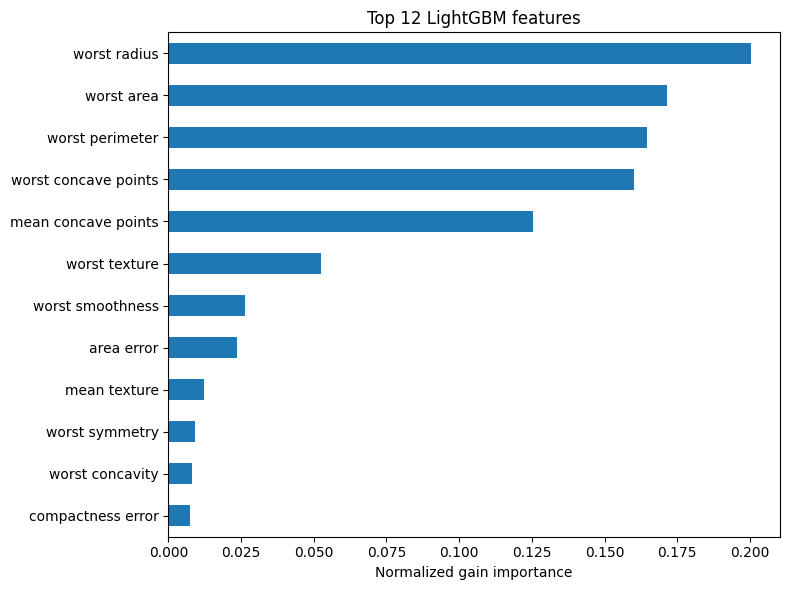

,gain
worst radius,0.200333
worst area,0.171418
worst perimeter,0.164611
worst concave points,0.160300
mean concave points,0.125561
worst texture,0.052527
worst smoothness,0.026225
area error,0.023671
mean texture,0.012231
worst symmetry,0.009152


In [14]:
# Gain importance measures how much the model's objective improved from splits using each feature.
gain_values = final_model.booster_.feature_importance(importance_type='gain')
gain_importance = pd.Series(gain_values, index=X.columns, name='gain')
if gain_importance.sum() > 0:
    gain_importance = gain_importance / gain_importance.sum()
gain_importance = gain_importance.sort_values(ascending=False)

gain_importance.head(12).sort_values().plot(kind='barh', figsize=(8, 6))
plt.xlabel('Normalized gain importance')
plt.title('Top 12 LightGBM features')
plt.tight_layout()
plt.show()

gain_importance.head(12).to_frame()

LightGBM also provides **split importance**, which counts how often a feature was used. Gain importance is often more informative because it measures total improvement, but neither method proves causality.

## 17. Common LightGBM parameters — simple reference

| Parameter | Simple meaning |
|---|---|
| `boosting_type` | Boosting method. `'gbdt'` is the standard choice; other options include `'dart'` and `'goss'`. |
| `num_leaves` | Maximum leaves per tree. One of the main complexity controls. |
| `max_depth` | Optional limit on tree depth. |
| `learning_rate` | Size of each tree's contribution. |
| `n_estimators` | Maximum number of trees. |
| `min_child_samples` | Minimum rows in a leaf. Larger values reduce overfitting. |
| `min_child_weight` | Minimum weighted information required in a child leaf. |
| `min_split_gain` | Minimum improvement required before making a split. |
| `subsample` | Fraction of rows sampled for a tree. |
| `subsample_freq` | How often row sampling is performed. `0` disables it. |
| `colsample_bytree` | Fraction of columns sampled for each tree. |
| `reg_alpha` | L1 regularization. |
| `reg_lambda` | L2 regularization. |
| `max_bin` | Number of histogram bins used for numeric values. |
| `class_weight` | Gives classes different importance. Useful for imbalance. |
| `importance_type` | Default feature-importance type returned by the sklearn wrapper. |
| `n_jobs` | Number of CPU threads. `-1` uses all available cores. |
| `random_state` | Random seed. |

## 18. Categorical features in LightGBM

LightGBM can use categorical features directly when they are represented correctly. With pandas data, a common workflow is:

```python
X['city'] = X['city'].astype('category')
model.fit(X_train, y_train, categorical_feature=['city'])
```

Important rules:

- Learn category handling from training data only.
- Make validation and test columns use compatible category definitions.
- Do not assign arbitrary ordinal meaning unless the category truly has an order.

## 19. Optional hyperparameter search

In [15]:
# This cell is provided as a reusable example and is not executed automatically
# because a search can take much longer than one normal fit.

# cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
# search_model = LGBMClassifier(
#     objective='binary',
#     random_state=RANDOM_STATE,
#     n_jobs=-1,
#     verbosity=-1,
# )
#
# parameter_distributions = {
#     'n_estimators': [100, 250, 500, 800],
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'num_leaves': [7, 15, 31, 63],
#     'max_depth': [-1, 3, 5, 8],
#     'min_child_samples': [10, 20, 40, 80],
#     'subsample': [0.7, 0.85, 1.0],
#     'subsample_freq': [0, 1],
#     'colsample_bytree': [0.7, 0.85, 1.0],
#     'reg_alpha': [0.0, 0.1, 1.0],
#     'reg_lambda': [0.0, 0.5, 1.0, 5.0],
# }
#
# search = RandomizedSearchCV(
#     estimator=search_model,
#     param_distributions=parameter_distributions,
#     n_iter=30,
#     scoring='roc_auc',
#     cv=cv,
#     random_state=RANDOM_STATE,
#     n_jobs=-1,
#     verbose=1,
# )
# search.fit(X_development, y_development)
# print(search.best_score_)
# print(search.best_params_)

### Important search parameters

| Parameter | Simple meaning |
|---|---|
| `n_iter` | Number of random parameter combinations to test. |
| `scoring='roc_auc'` | Metric used to rank combinations. |
| `cv` | Cross-validation plan used within development data. |
| `n_jobs=-1` | Run multiple fits in parallel when possible. |
| `random_state` | Repeat the same random combinations. |

## 20. Save and reload the model

In [16]:
model_path = Path('lightgbm_breast_cancer_model.joblib')
joblib.dump(final_model, model_path)

reloaded_model = joblib.load(model_path)
original_predictions = final_model.predict(X_test)
reloaded_predictions = reloaded_model.predict(X_test)

print('Saved to:', model_path.resolve())
print('Reloaded predictions are identical:', np.array_equal(original_predictions, reloaded_predictions))

Saved to: /mnt/data/lightgbm_breast_cancer_model.joblib
Reloaded predictions are identical: True


## 21. Practical tuning guide

| Situation | Parameters to inspect first |
|---|---|
| Model underfits | Increase `num_leaves`, reduce `min_child_samples`, add trees, or raise depth carefully. |
| Model overfits | Reduce `num_leaves`, set `max_depth`, increase `min_child_samples`, add regularization, or sample rows/columns. |
| Training is slow | Reduce `n_estimators`, increase `learning_rate` moderately, reduce feature count, or adjust `max_bin`. |
| Classes are imbalanced | Evaluate precision/recall and consider `class_weight` or `scale_pos_weight`. |
| Validation curve is noisy | Increase validation size, use cross-validation, or simplify the model. |
| Too many warnings about splits | Trees may already be constrained; inspect leaf and split parameters rather than blindly suppressing warnings. |

## 22. Common mistakes

1. Setting a very large `num_leaves` on a small dataset.
2. Using `subsample < 1` but leaving `subsample_freq=0`, which disables row subsampling.
3. Selecting parameters with the test set.
4. One-hot encoding high-cardinality categories without comparing native categorical handling.
5. Comparing only training scores.
6. Treating feature importance as causal evidence.
7. Ignoring the probability threshold when business costs are asymmetric.

## 23. Exercises

1. Compare `num_leaves=7`, `15`, `31`, and `63`.
2. Add `max_depth=4` and inspect the learning curve.
3. Disable row and column sampling.
4. Change the early-stopping patience from 75 to 20.
5. Compare gain importance with split importance.
6. Optimize recall by selecting a custom probability threshold.
7. Replace the dataset using the CSV template below.

## 24. Template for your own CSV dataset

In [17]:
# df = pd.read_csv('your_data.csv')
# target_column = 'target'
#
# X = df.drop(columns=[target_column])
# y = df[target_column]
#
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y,
#     test_size=0.30,
#     stratify=y,
#     random_state=RANDOM_STATE,
# )
# X_validation, X_test, y_validation, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=0.50,
#     stratify=y_temp,
#     random_state=RANDOM_STATE,
# )
#
# categorical_columns = ['city', 'product_type']
# for column in categorical_columns:
#     categories = X_train[column].astype('category').cat.categories
#     X_train[column] = pd.Categorical(X_train[column], categories=categories)
#     X_validation[column] = pd.Categorical(X_validation[column], categories=categories)
#     X_test[column] = pd.Categorical(X_test[column], categories=categories)

## 25. Final checklist

- [x] Separate training, validation, and test sets
- [x] Stratified splitting
- [x] Every used model and fit parameter explained
- [x] Native validation-based early stopping
- [x] Final retraining using the selected tree count
- [x] Test set evaluated once
- [x] Multiple classification metrics
- [x] Learning curve
- [x] Gain feature importance
- [x] Optional hyperparameter search
- [x] Model saving and reloading

### Official documentation

- [LightGBM LGBMClassifier](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMClassifier.html)
- [LightGBM early stopping](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.early_stopping.html)
- [LightGBM parameters](https://lightgbm.readthedocs.io/en/stable/Parameters.html)